In [1]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation

import matplotlib
import matplotlib.pyplot as plt

In [2]:
#set up cosmology

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

Plan:

1. modify COCOA-CosmoLike to output the linear and nonlinear matter power spectrum used

2. using the same k-z grids in ccl, build and comapre the matter power spectrum

In [3]:
filepath = './cocoa/Cocoa/projects/roman_fourier/chains/roman_setup0_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk.txt')
lnPk_cocoa = np.loadtxt(filepath+'pknl.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
#--------------------------------------------#
#--------------------unit--------------------#
#--------------------------------------------#
#                      cosmolike        ccl
#             z        unitless          a 
#             k          1/Mpc          1/Mpc
#            lnPk       Mpc/h^3          Mpc
#          lnPk_lin     Mpc/h^3          Mpc
#--------------------------------------------#
#--------------------------------------------#
# covert the unit to that used by ccl
lnPk_cocoa     = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa     = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa   = np.log(k_pk_cocoa)
# covert the Pk class used by ccl
pk2_cocoa     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
# calculate a comparable Pk simulated by ccl
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)


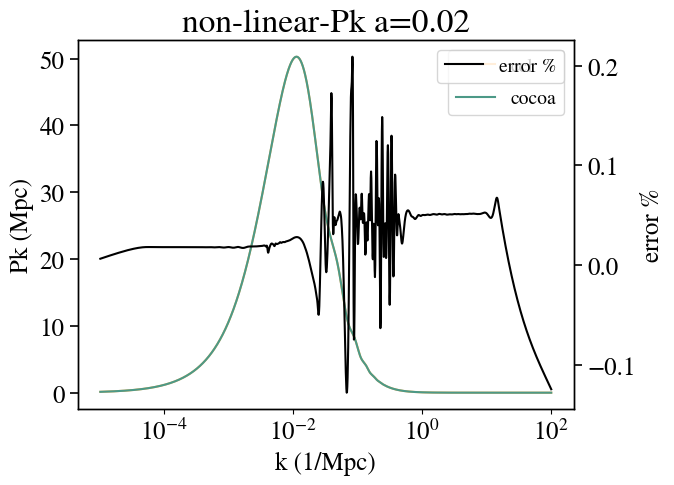

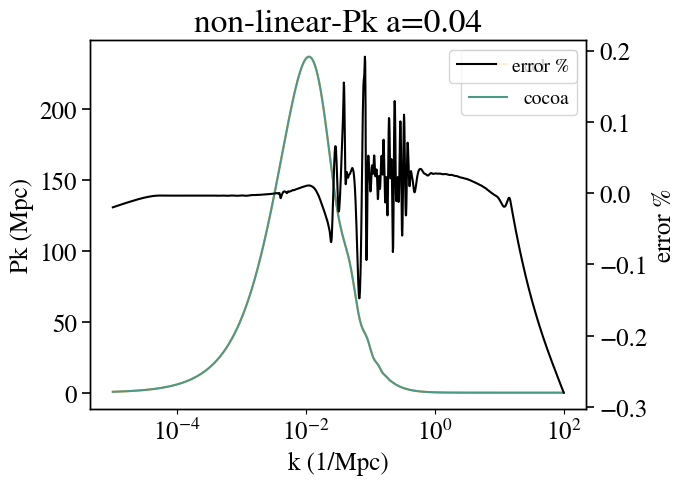

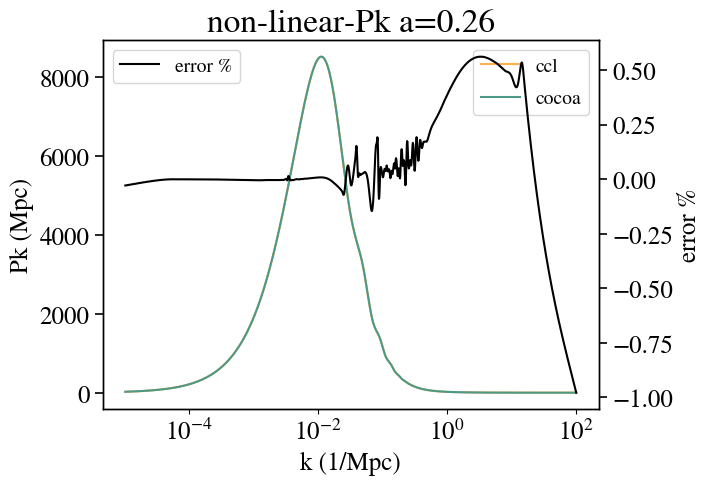

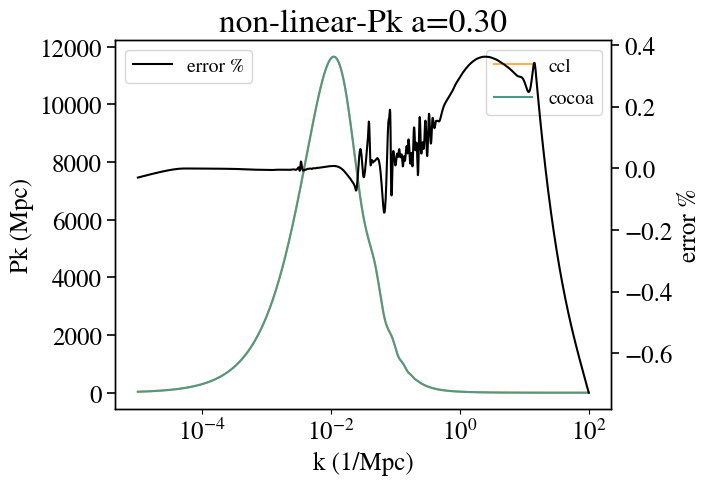

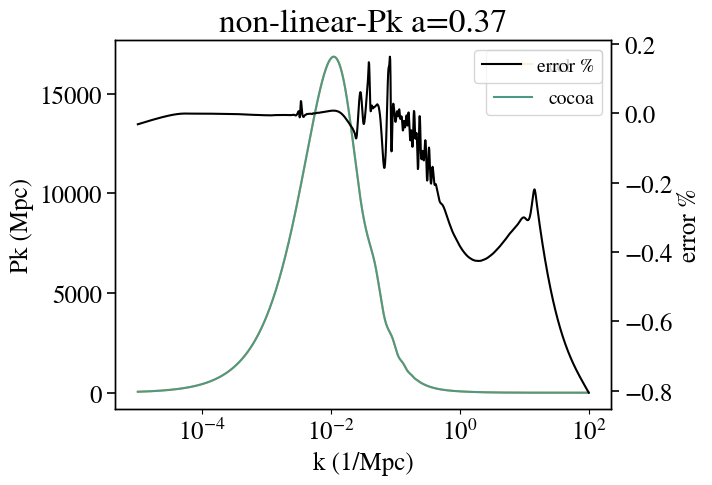

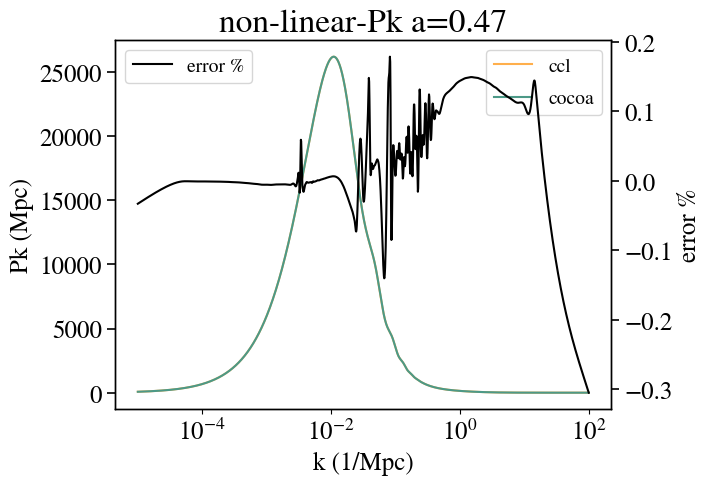

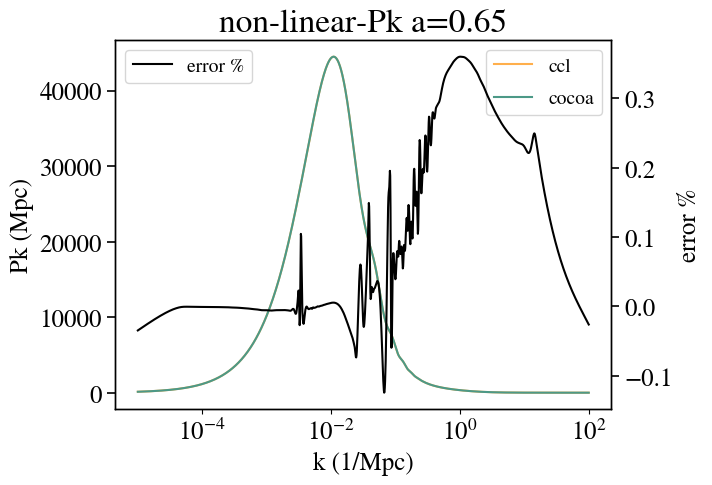

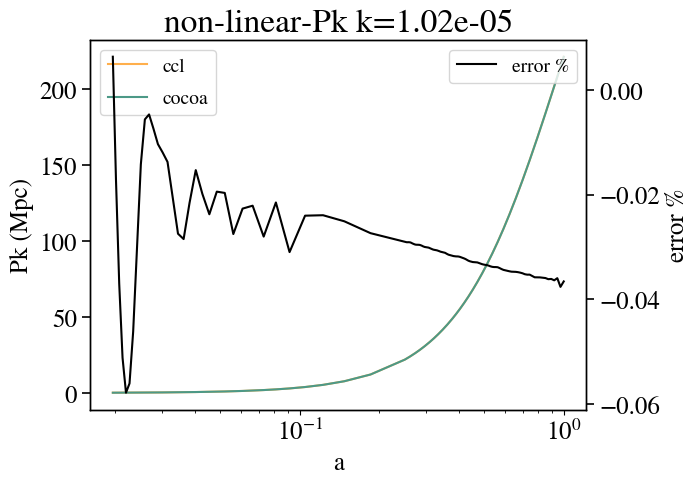

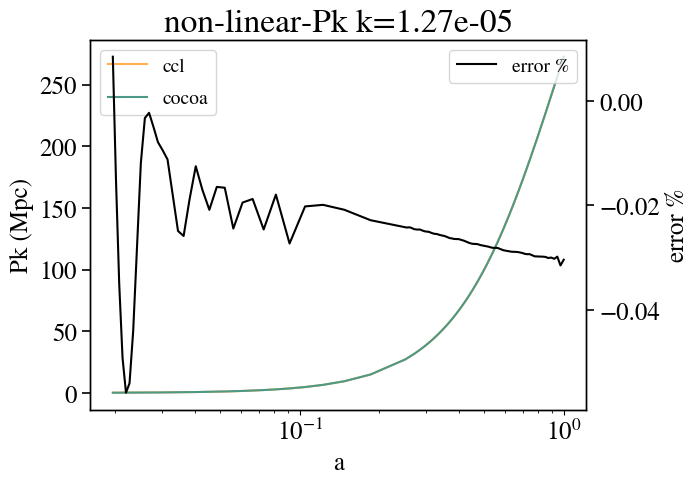

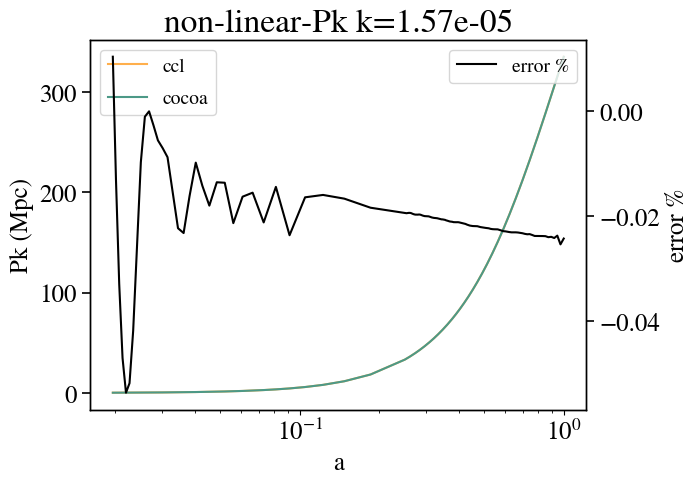

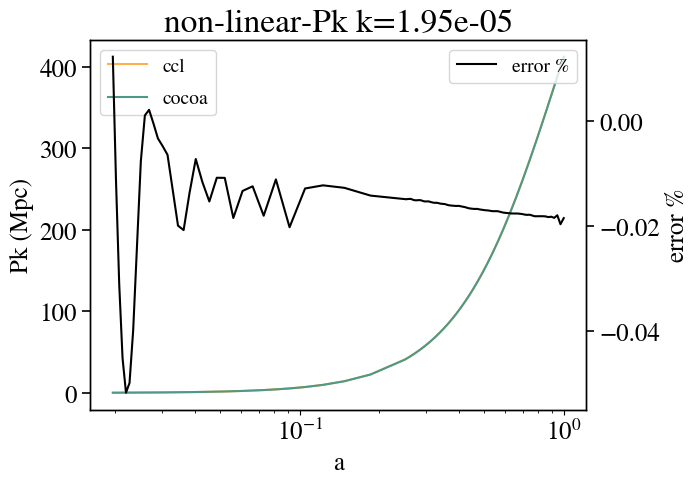

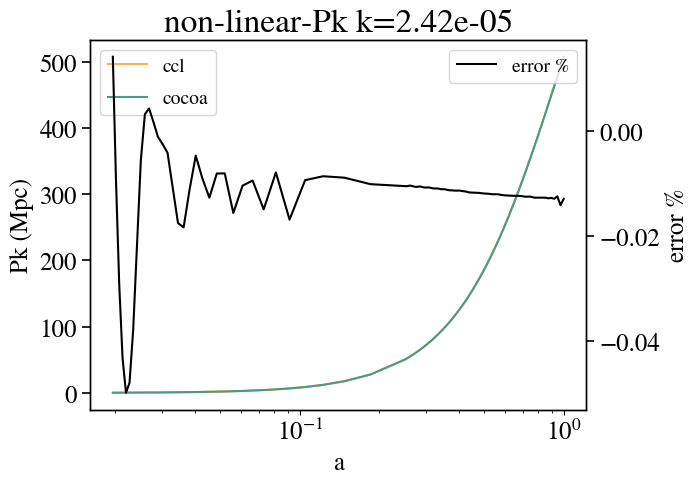

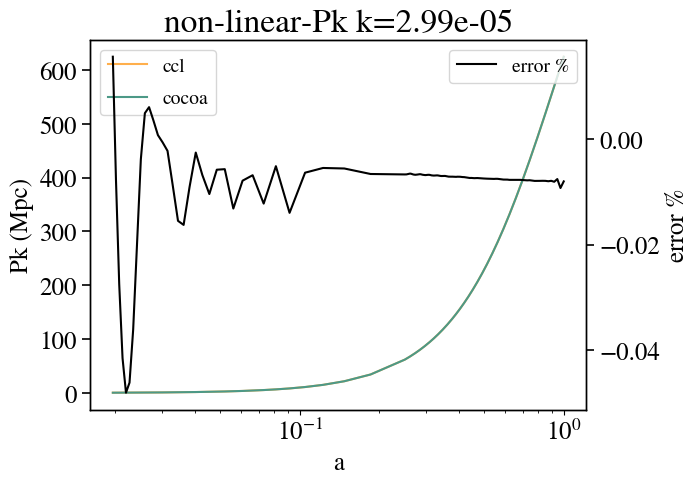

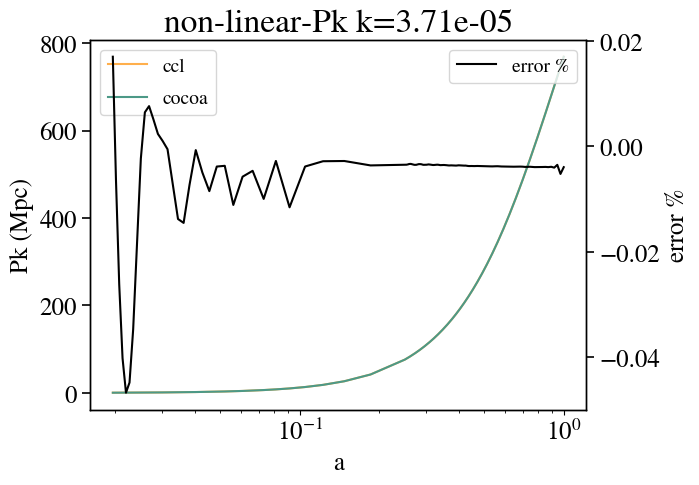

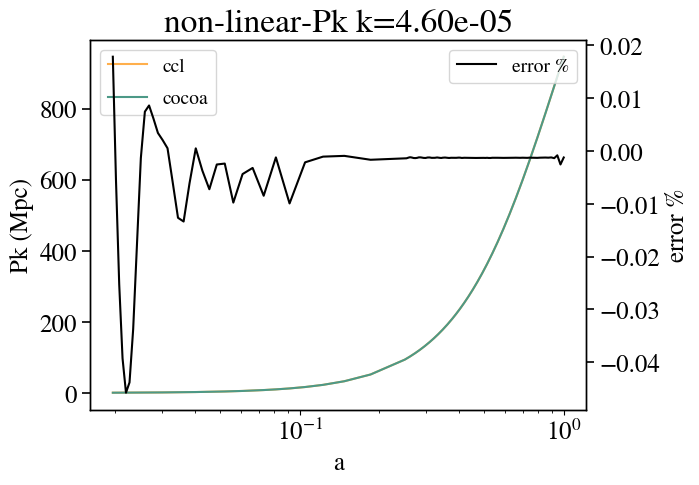

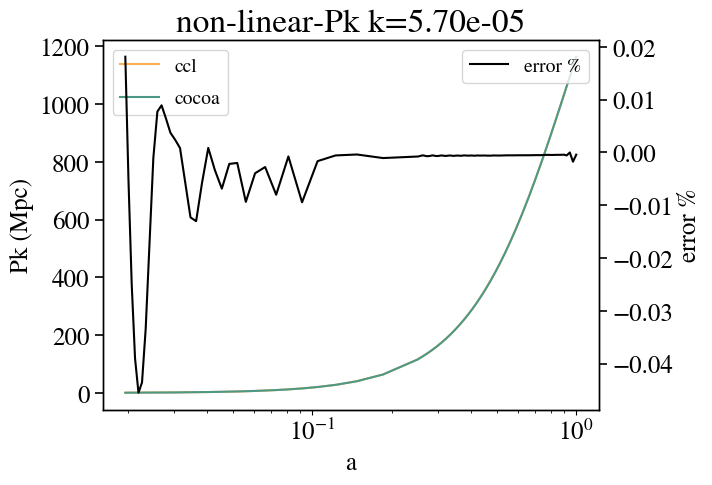

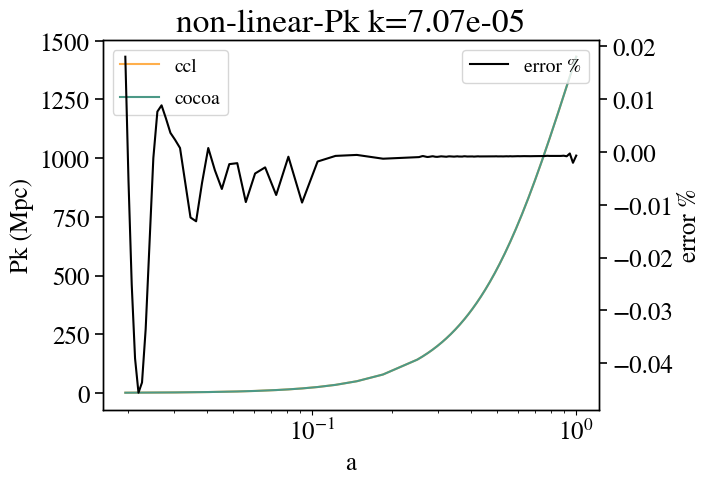

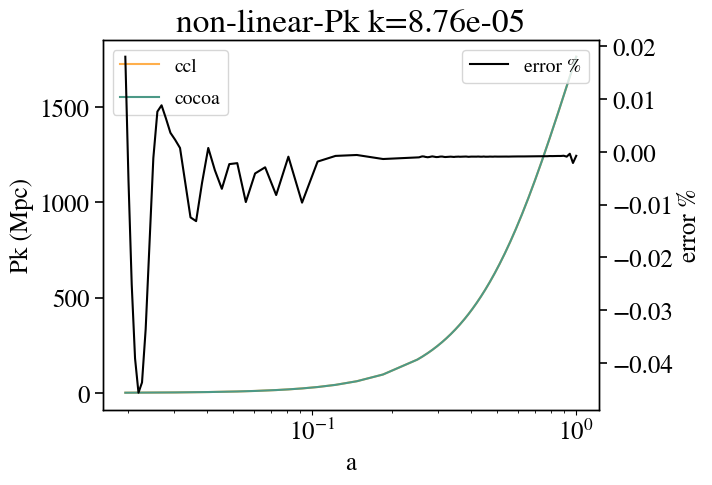

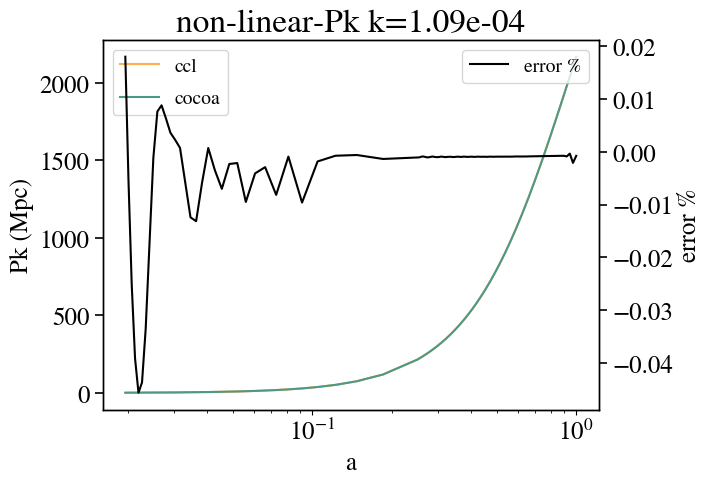

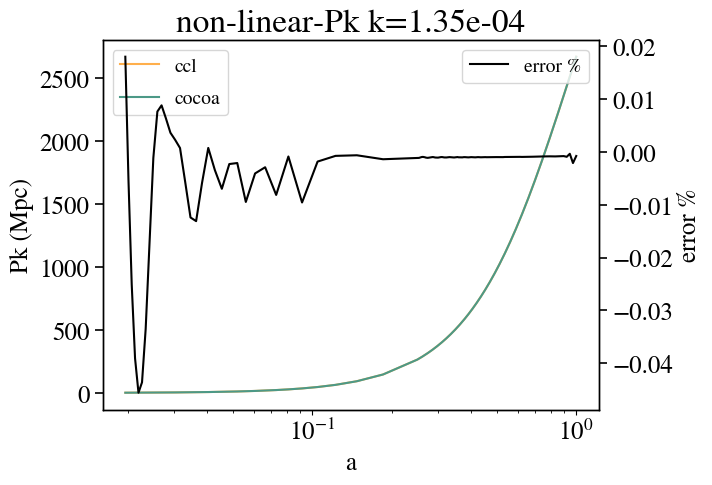

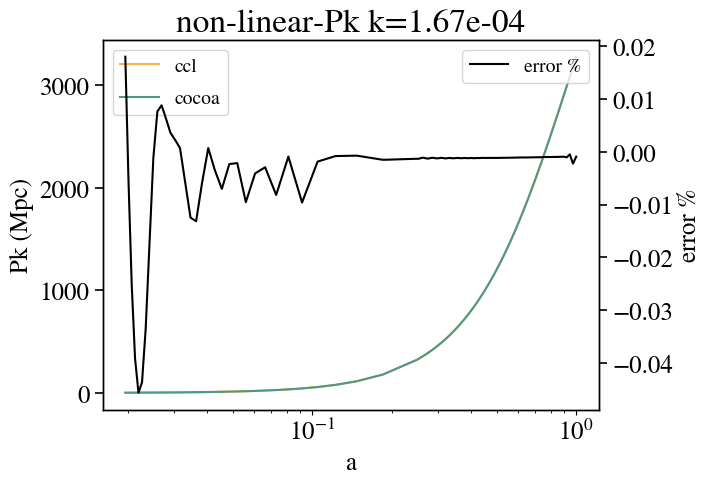

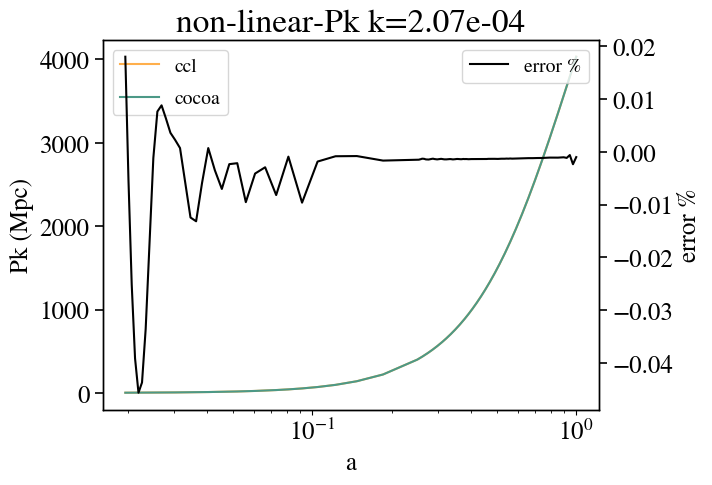

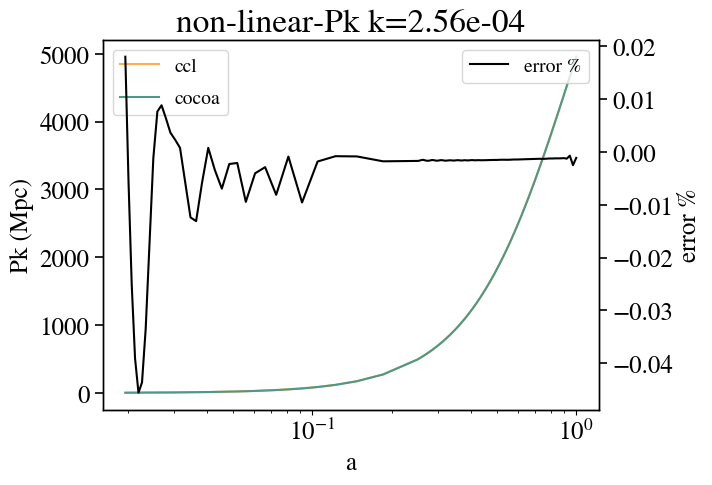

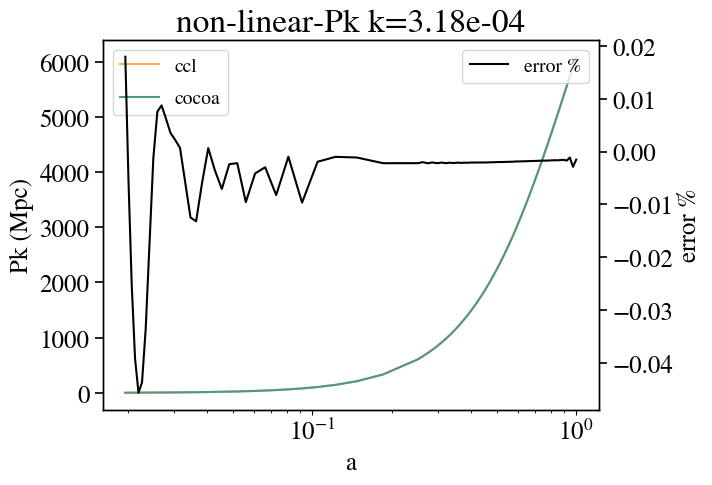

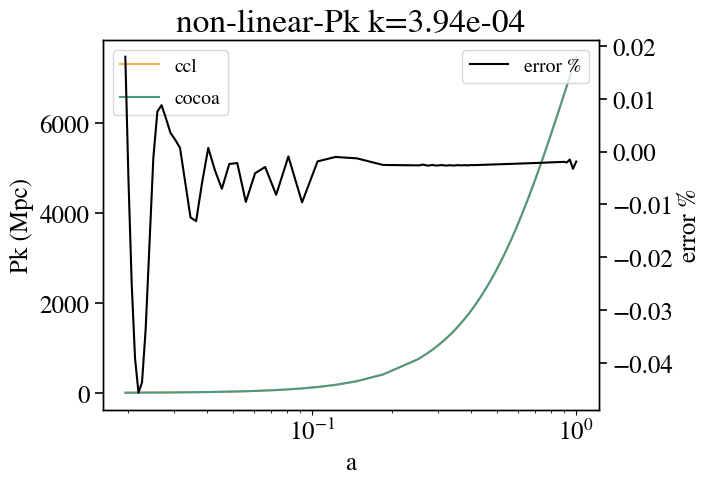

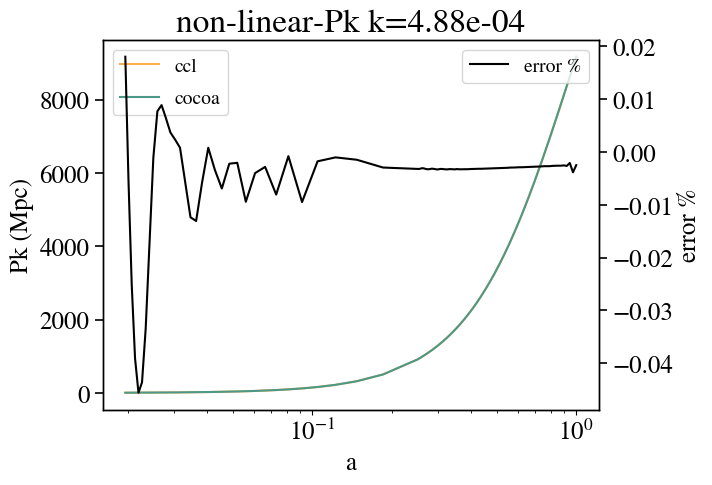

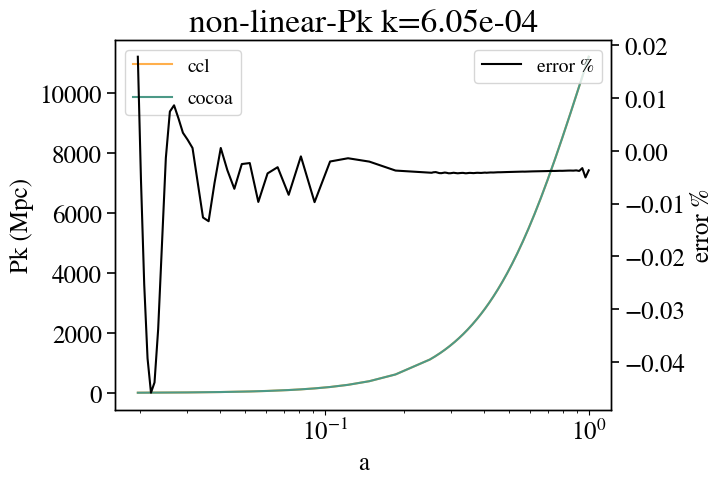

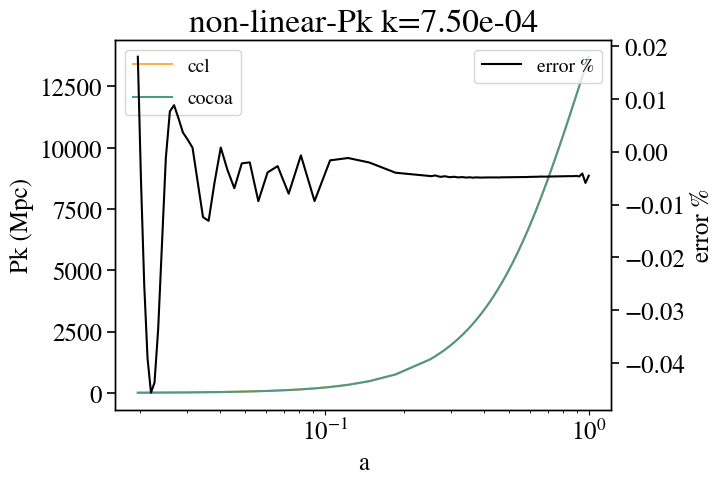

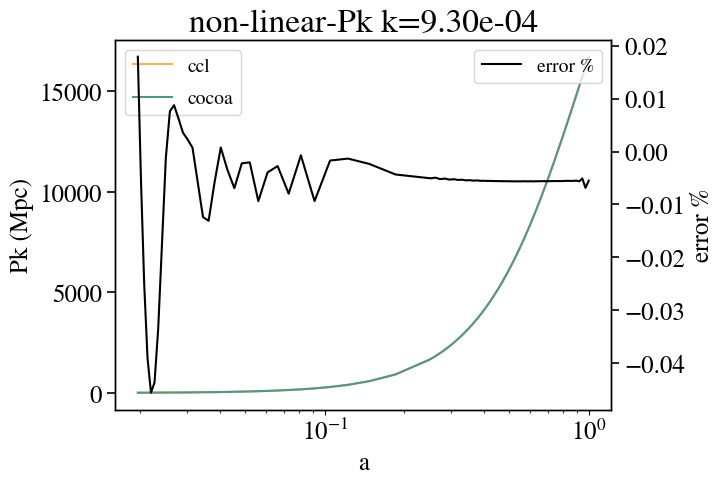

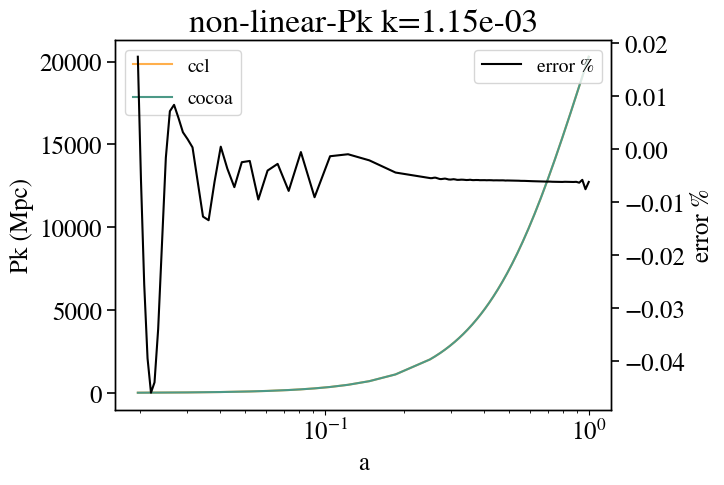

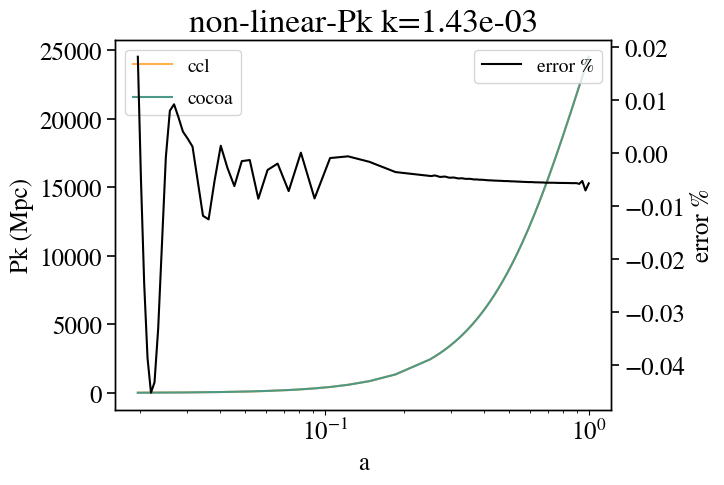

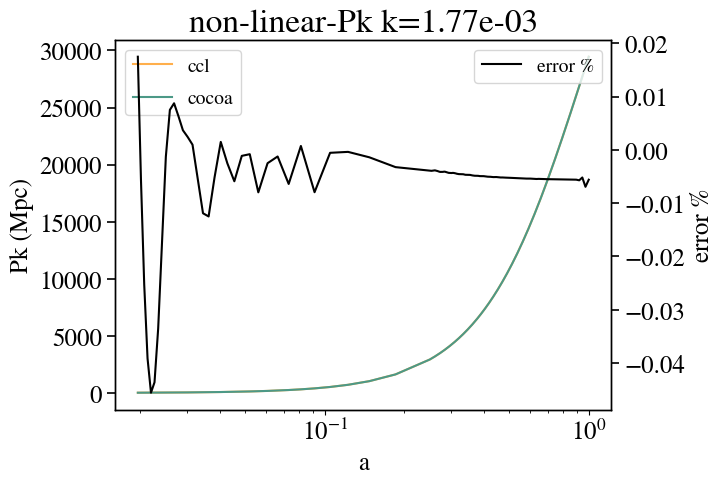

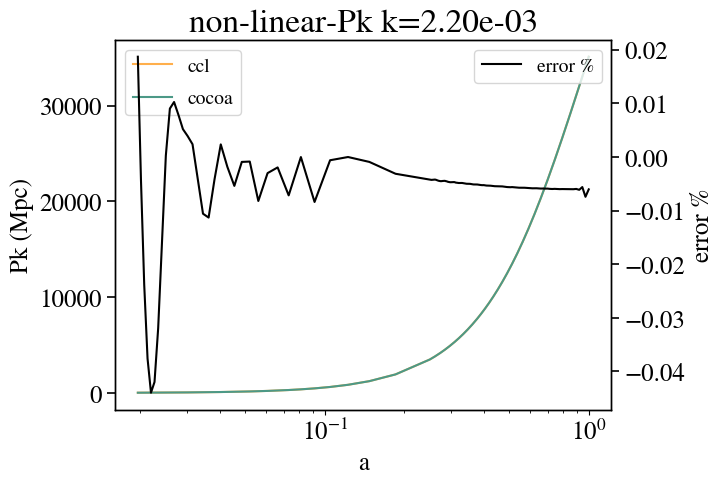

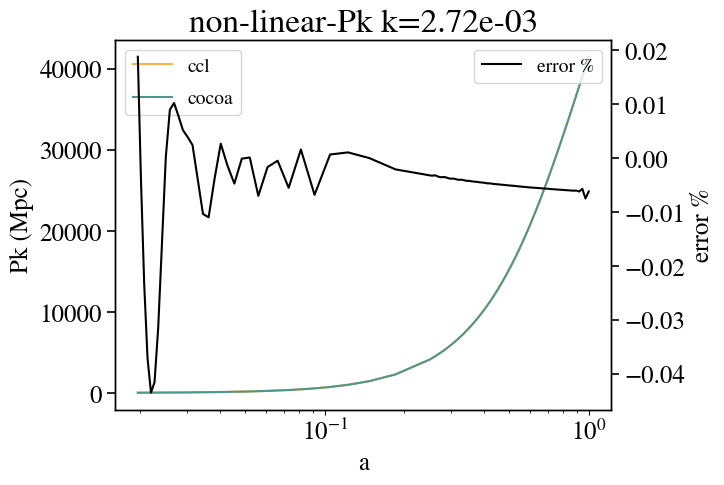

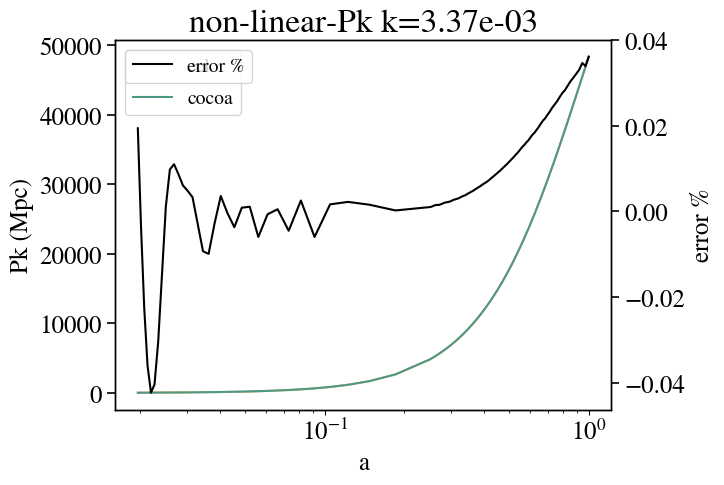

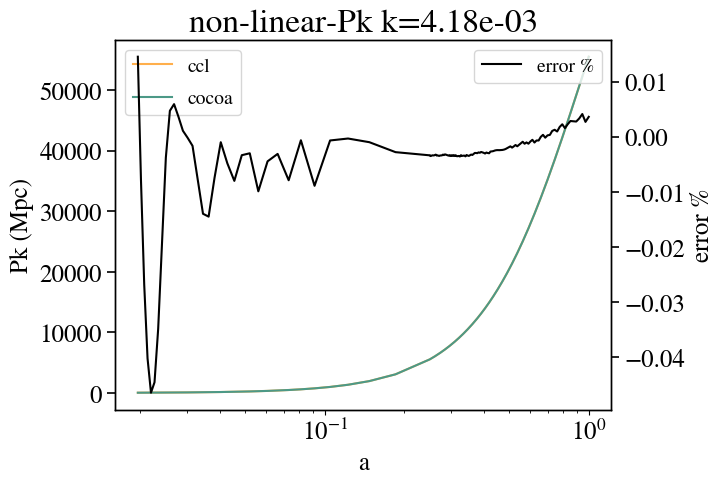

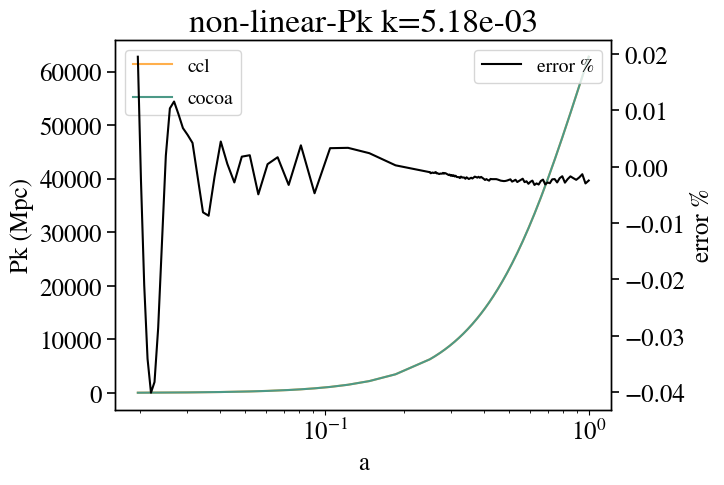

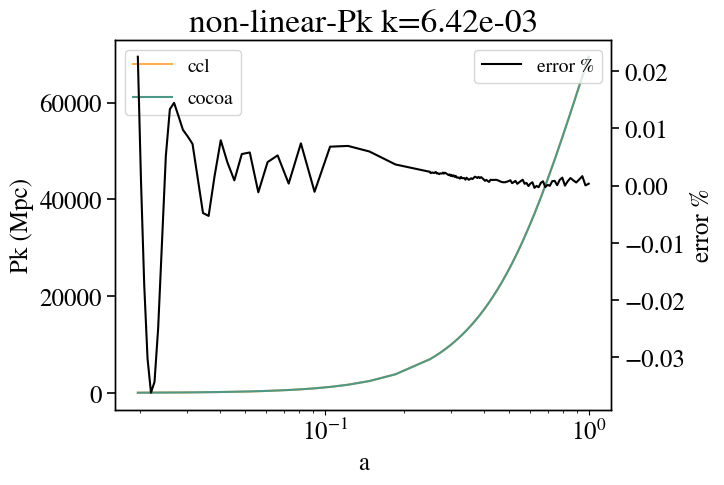

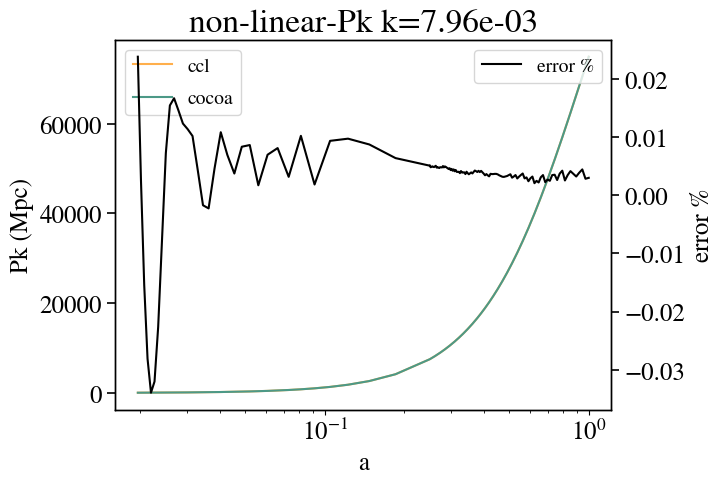

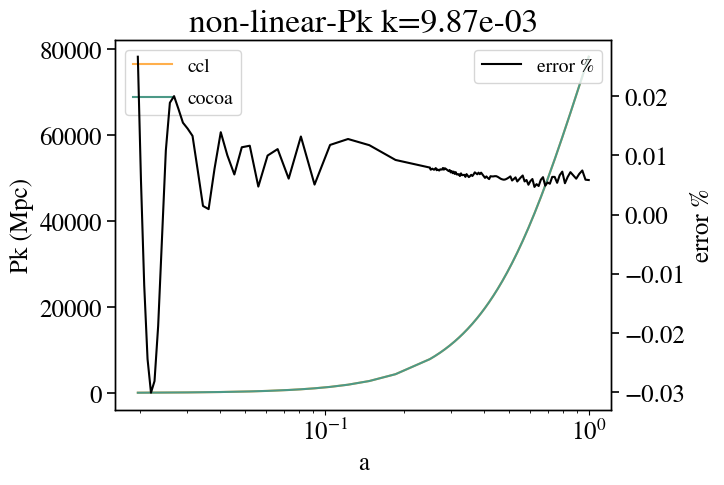

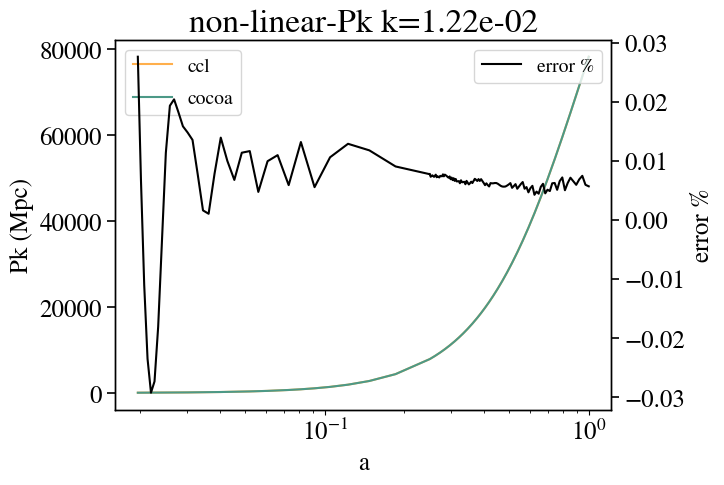

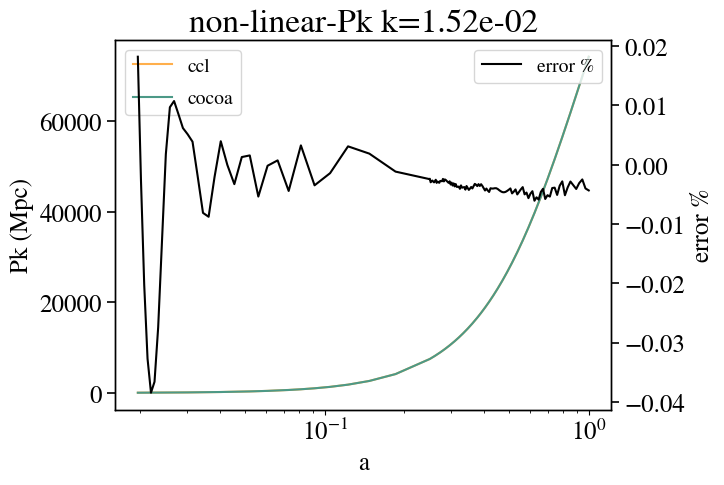

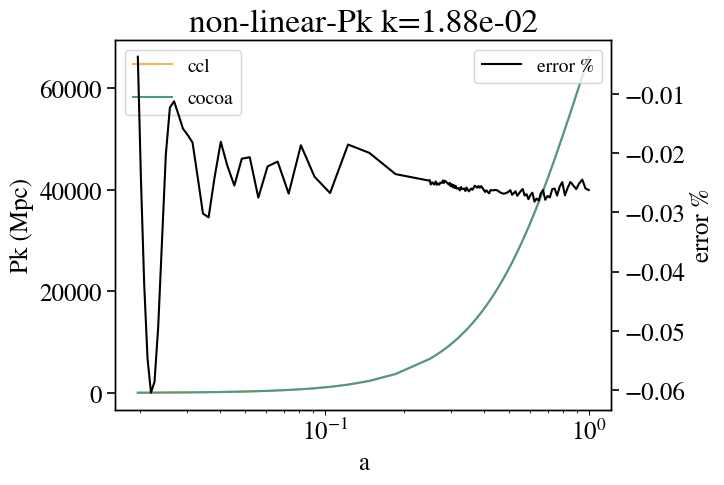

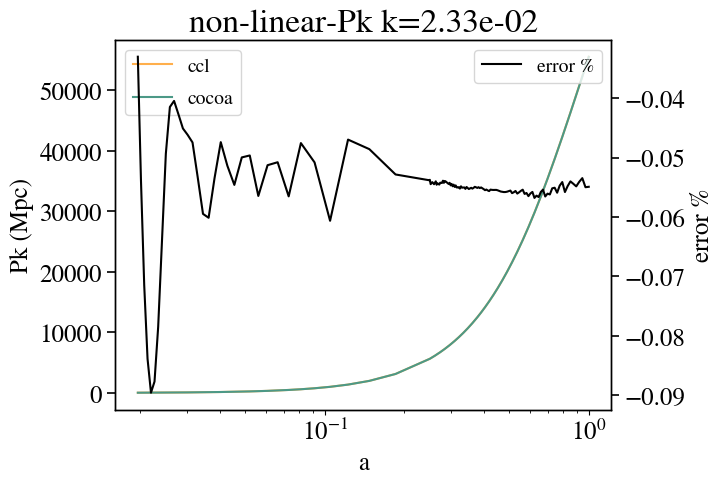

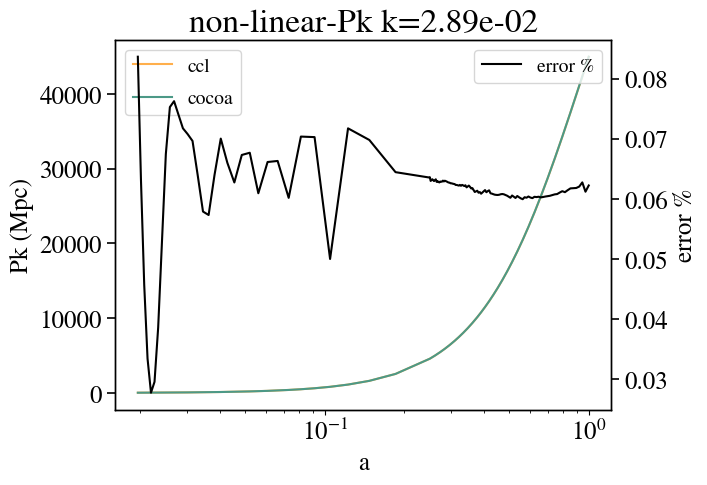

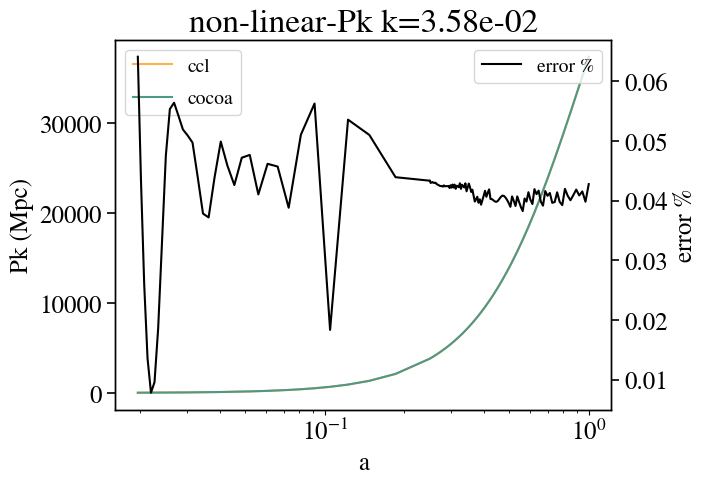

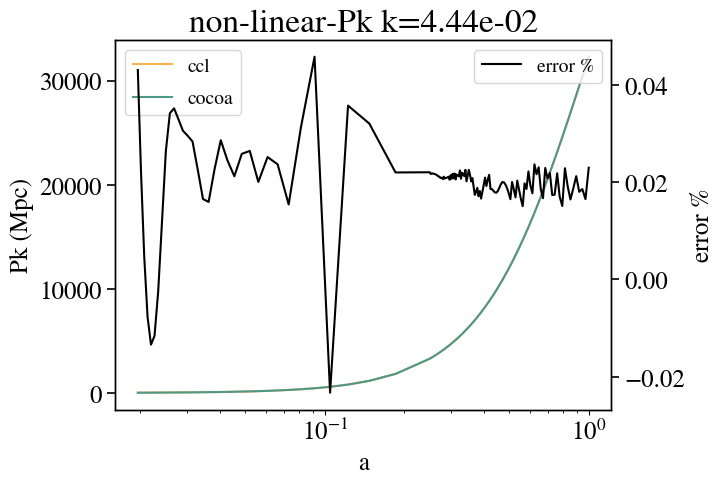

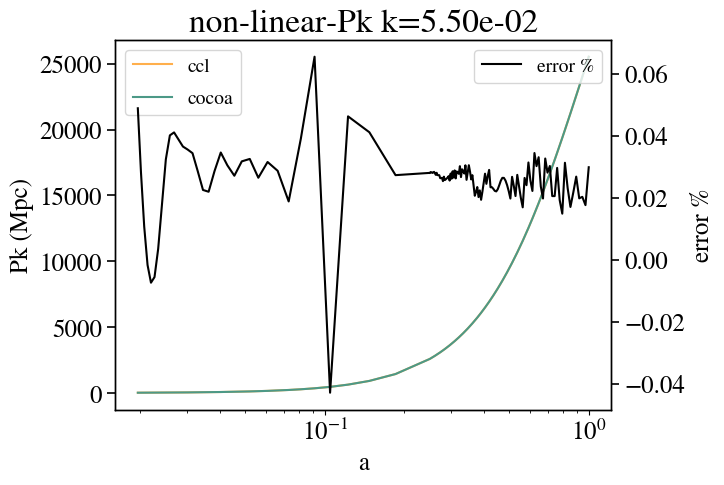

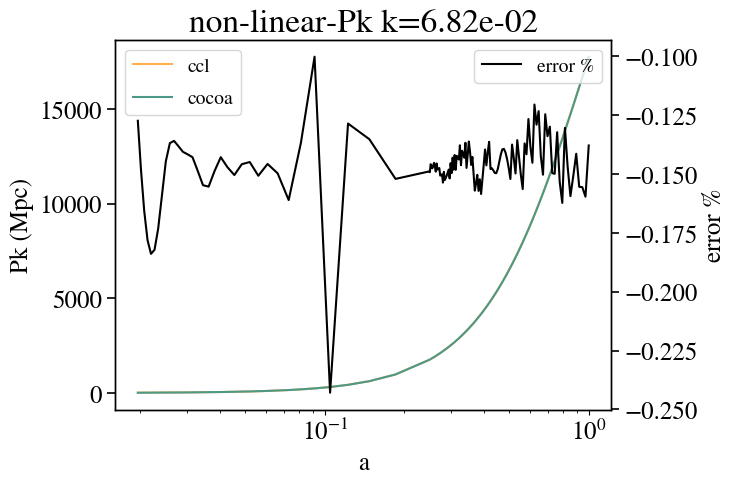

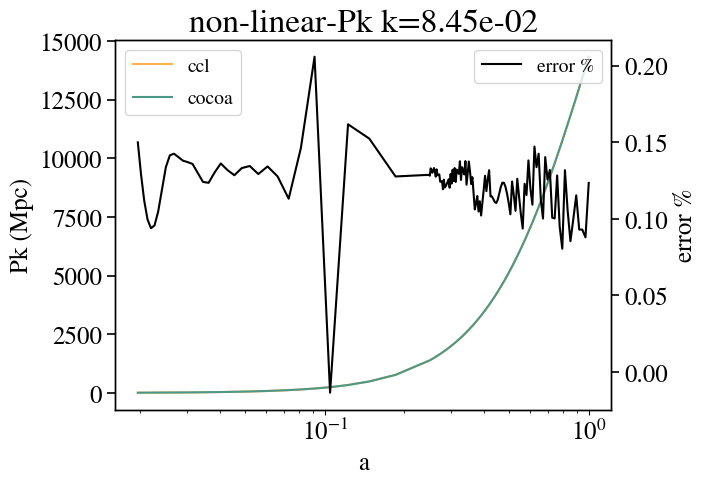

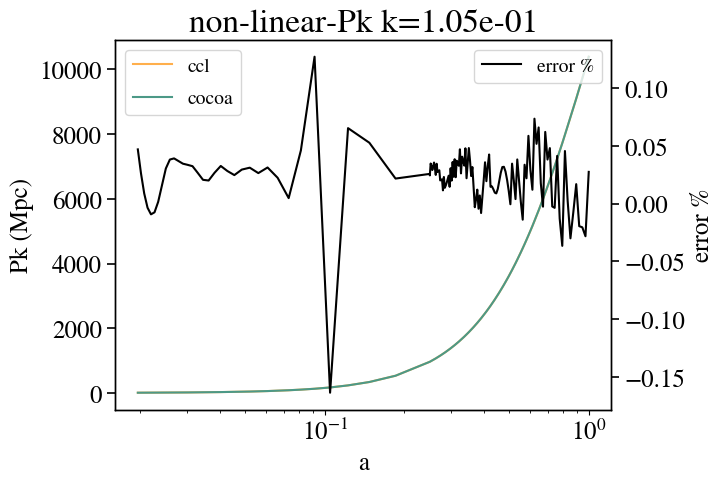

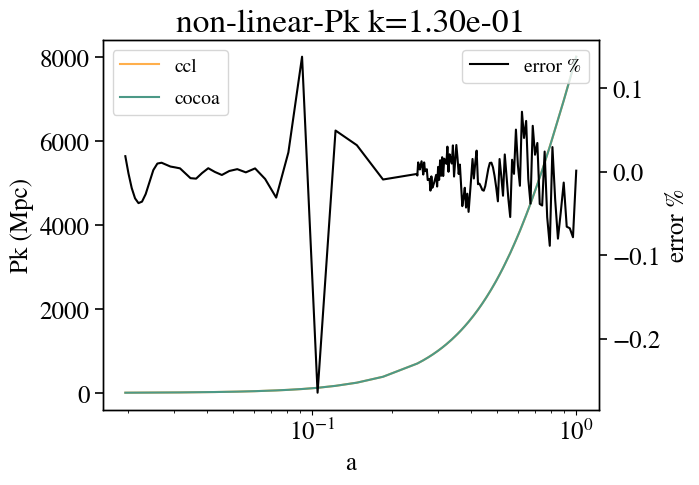

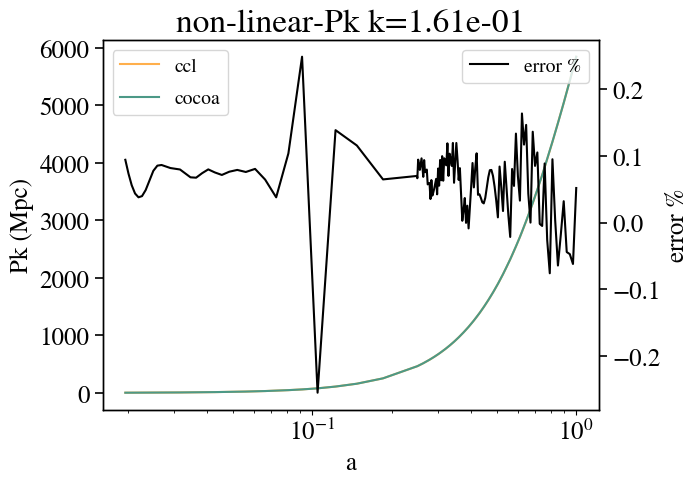

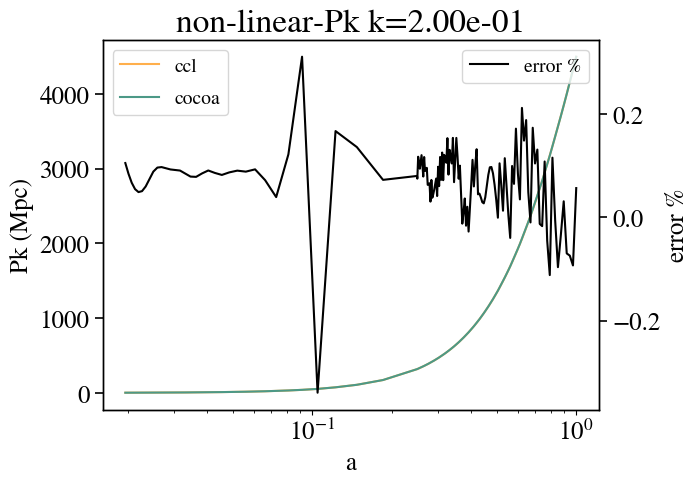

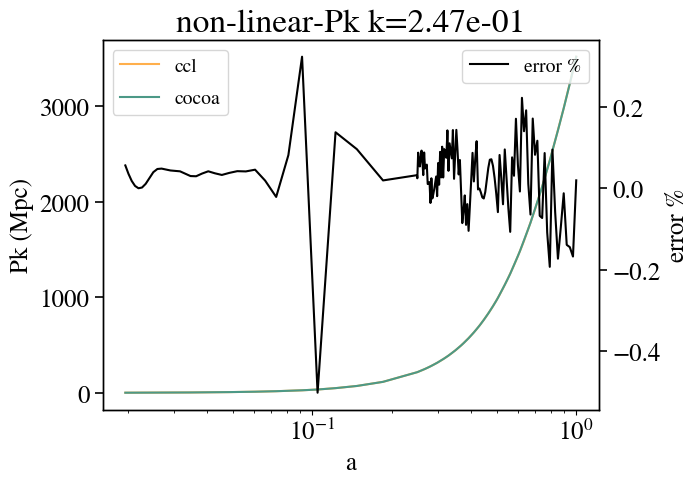

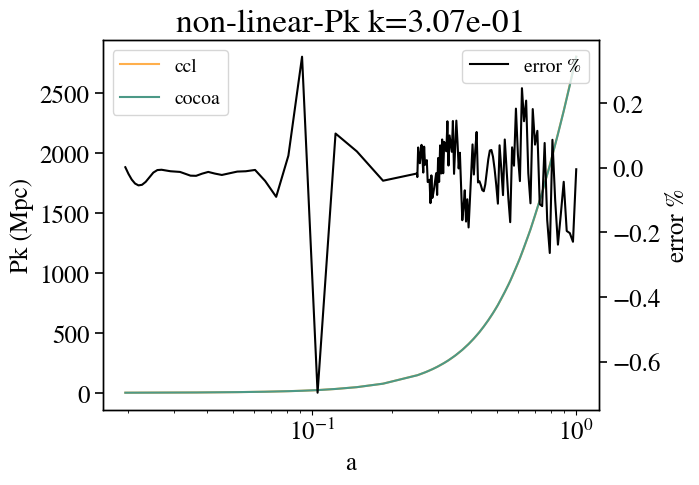

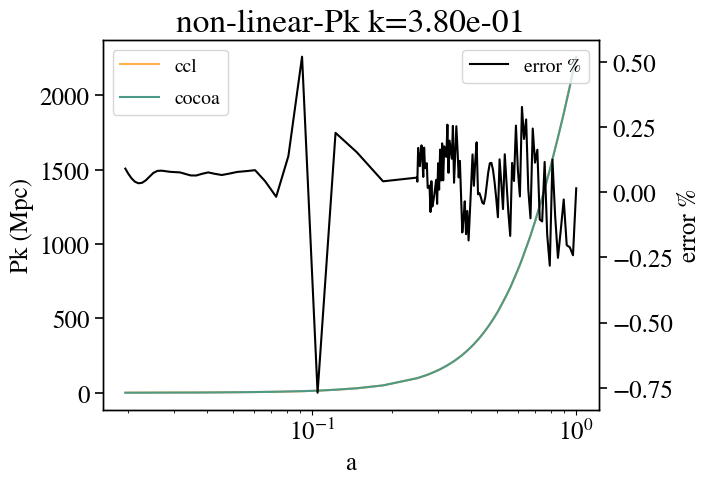

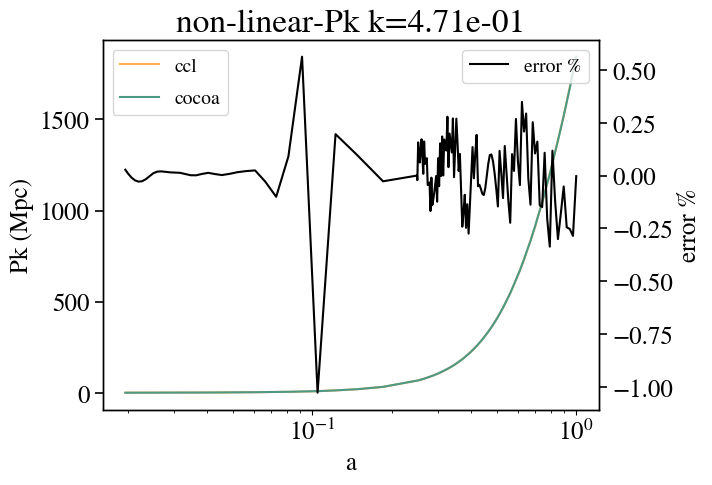

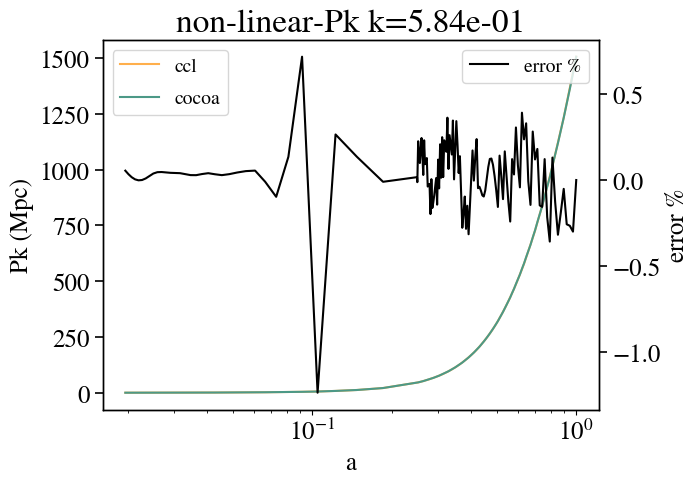

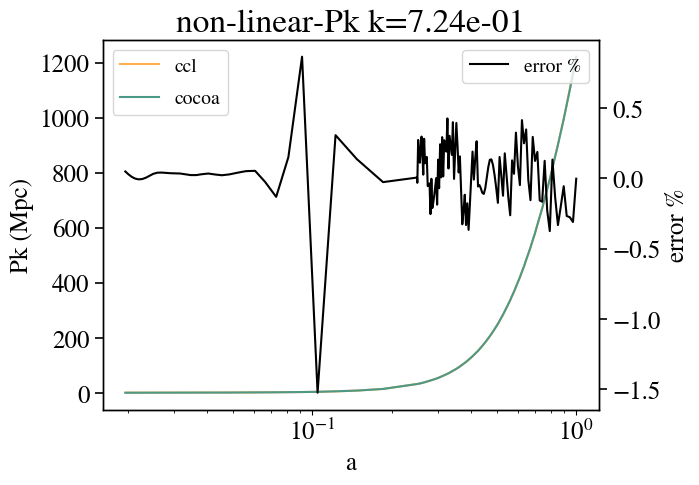

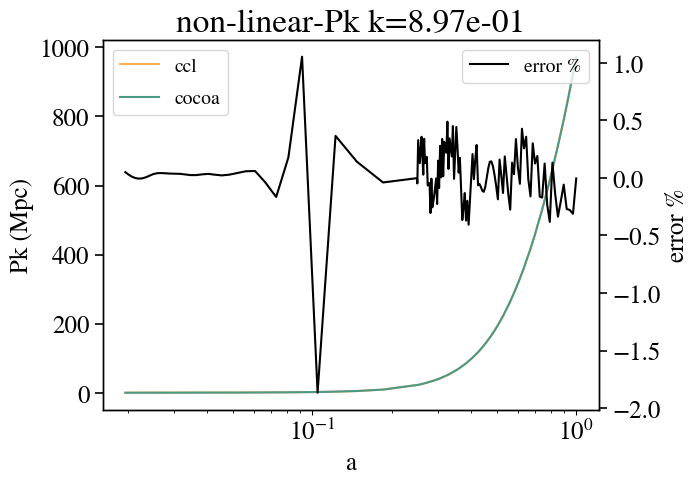

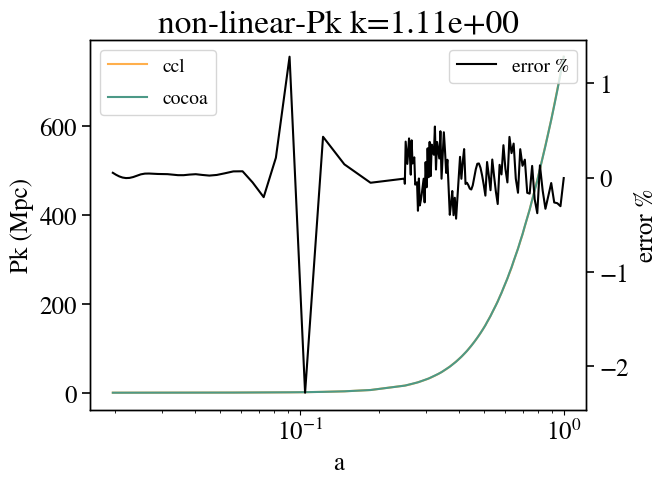

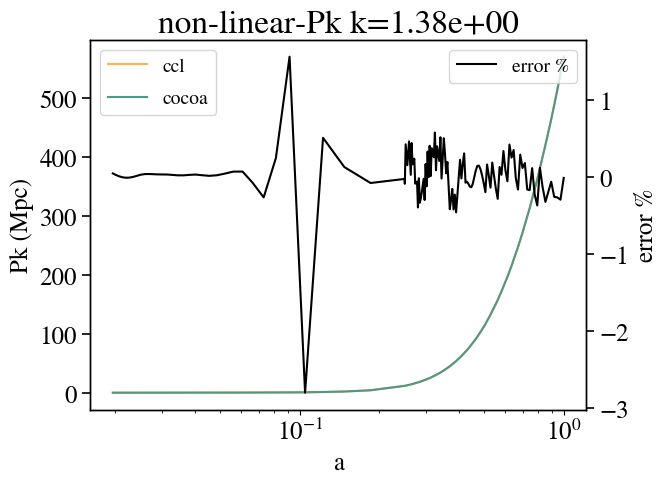

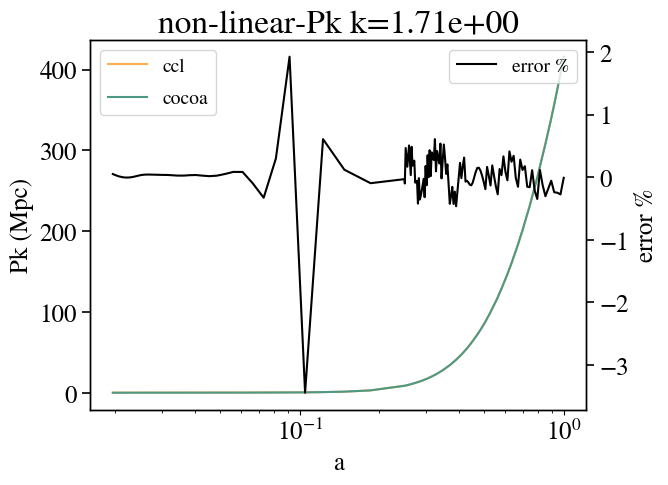

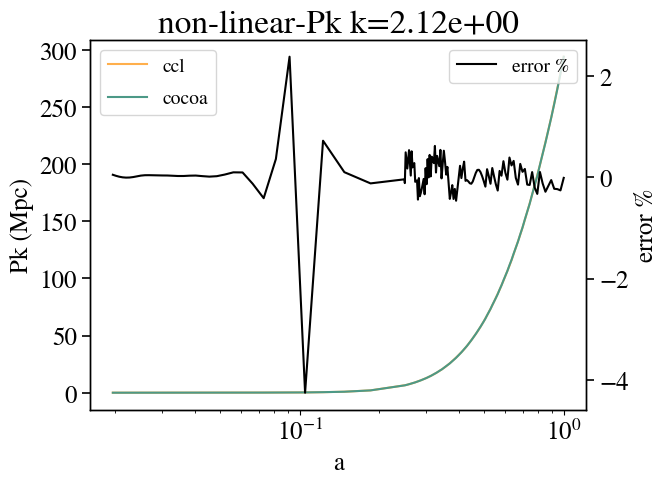

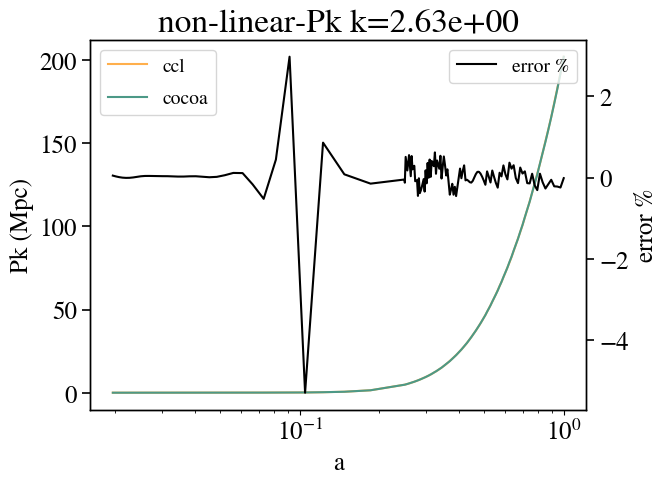

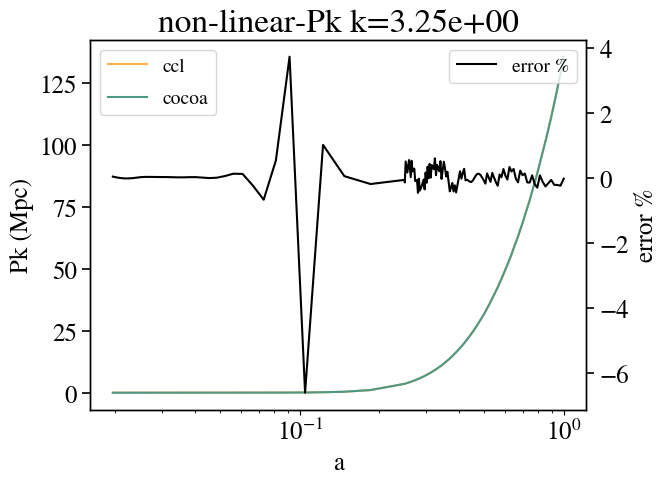

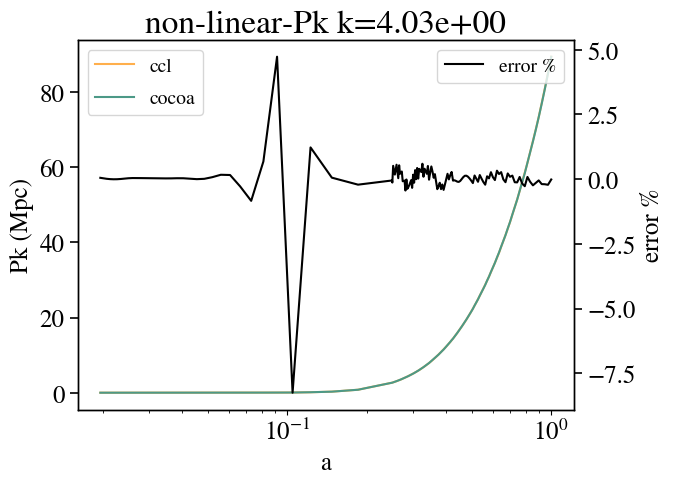

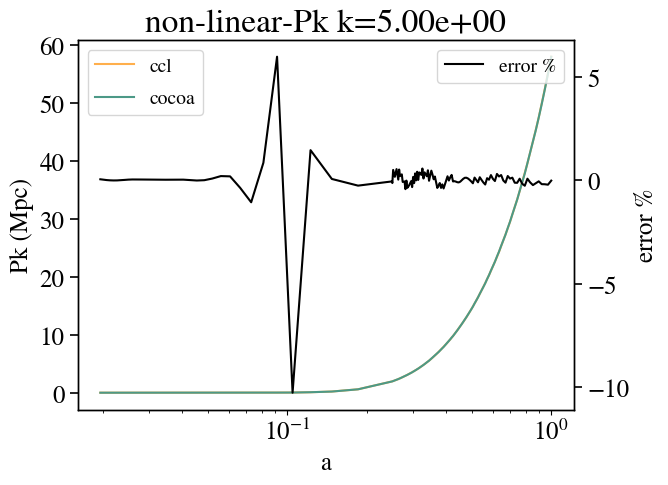

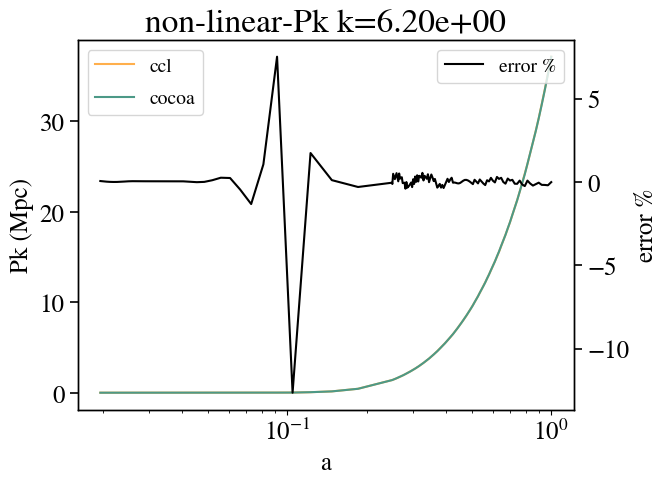

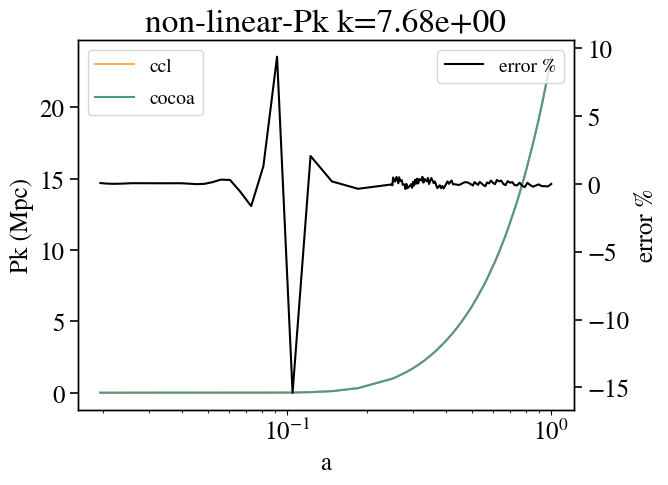

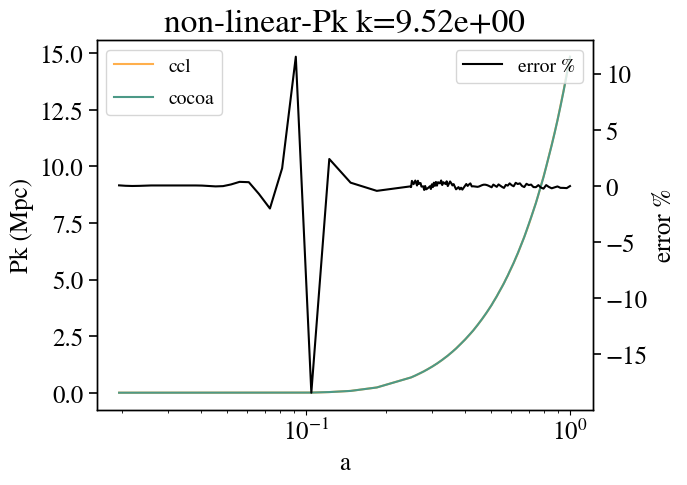

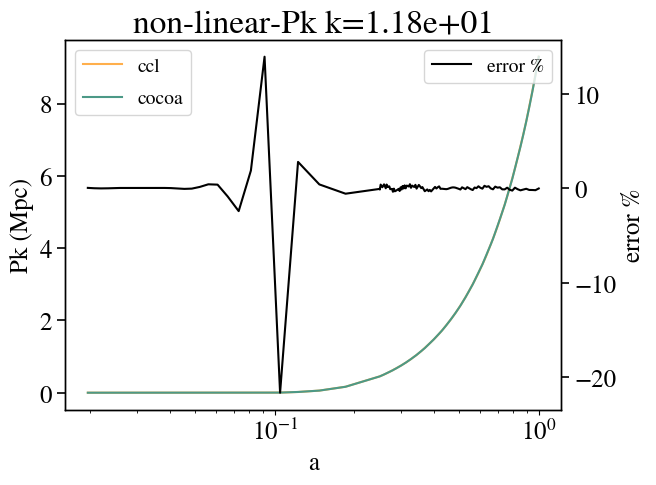

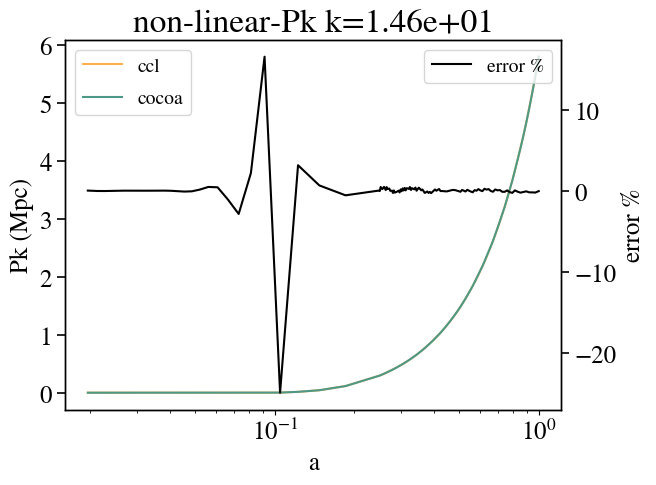

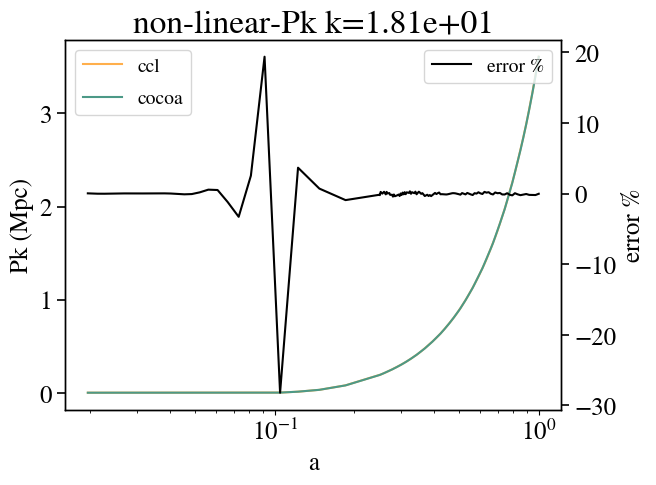

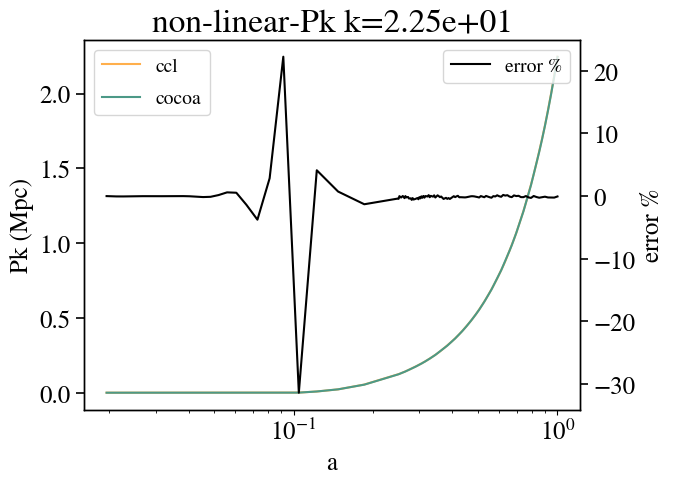

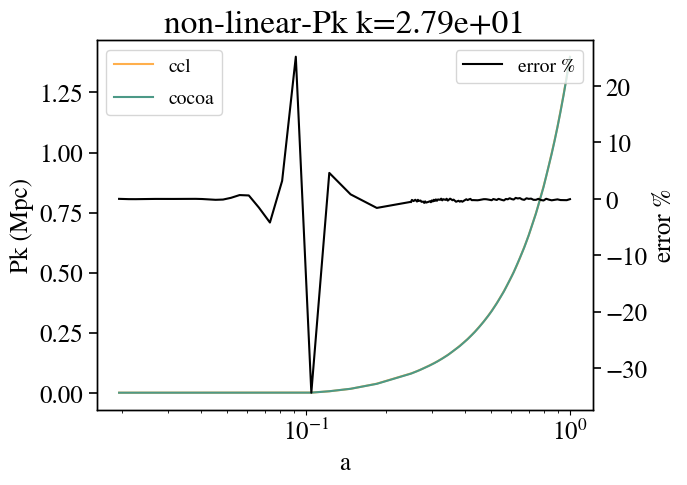

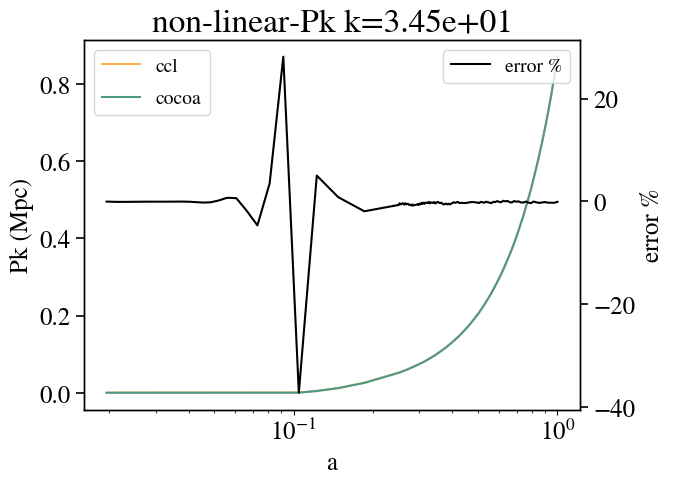

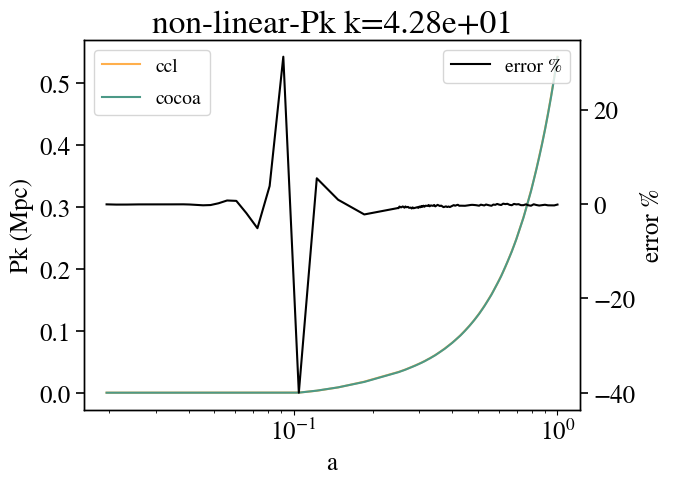

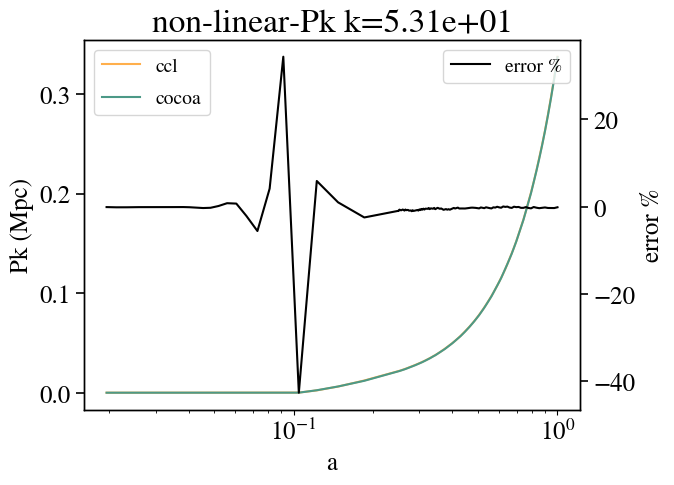

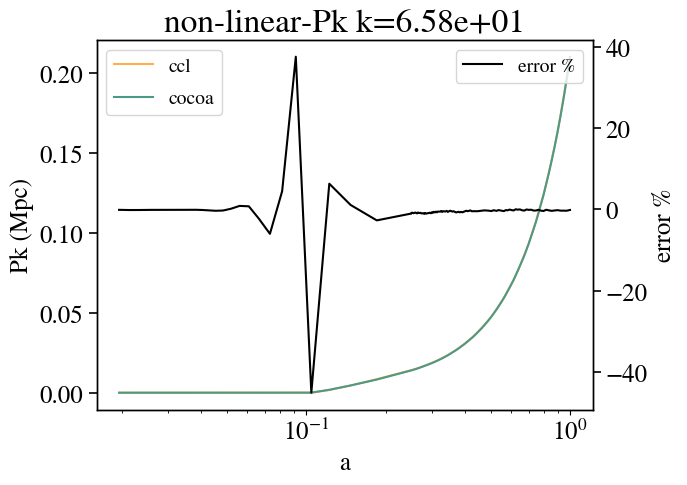

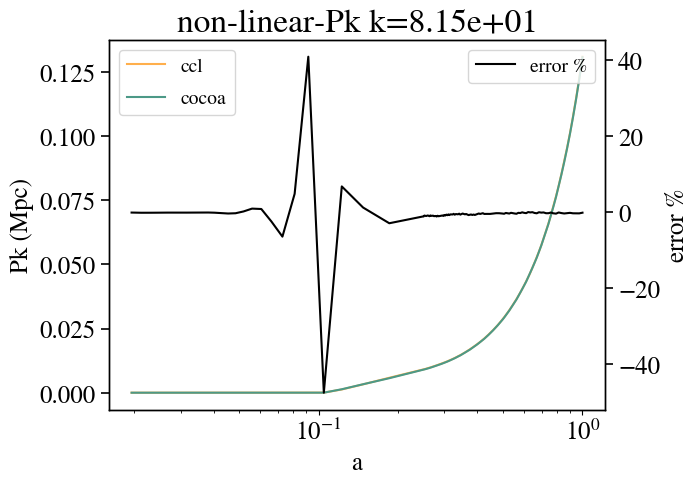

In [6]:
pk_cocoa = pk2_cocoa.get_spline_arrays()[2]
pk_ccl   = pk2_ccl.get_spline_arrays()[2]
Len_a = len(a_pk_cocoa)
Len_k = len(lnk_pk_cocoa)
for i in range(0, Len_a, 20):
    fig, ax1 = plt.subplots()
    
    a = a_pk_cocoa[i]
    ax1.plot(np.exp(lnk_pk_cocoa),   pk_ccl[i], color='#FFAF4C', label='ccl')
    ax1.plot(np.exp(lnk_pk_cocoa), pk_cocoa[i], color='#4C9987', label='cocoa')
    ax1.set_xscale('log')
    ax1.set_xlabel('k (1/Mpc)')
    ax1.set_ylabel('Pk (Mpc)')
    ax1.legend()
    
    ax2 = ax1.twinx()
    ax2.plot(np.exp(lnk_pk_cocoa), (pk_cocoa[i]-pk_ccl[i])/(pk_ccl[i])*100, color='k', label='error %')
    ax2.set_xscale('log')
    ax2.set_ylabel('error %')
    ax2.legend()
    
    plt.title(f'non-linear-Pk a={a:.2f}')
    plt.show()
    
for i in range(0, Len_k, 20):
    fig, ax1 = plt.subplots()
    
    k = np.exp(lnk_pk_cocoa[i])
    ax1.plot(a_pk_cocoa,   pk_ccl[:,i], color='#FFAF4C', label='ccl')
    ax1.plot(a_pk_cocoa, pk_cocoa[:,i], color='#4C9987', label='cocoa')
    ax1.set_xscale('log')
    ax1.set_xlabel('a')
    ax1.set_ylabel('Pk (Mpc)')
    ax1.legend()
    
    ax2 = ax1.twinx()
    ax2.plot(a_pk_cocoa, (pk_cocoa[:,i]-pk_ccl[:,i])/(pk_ccl[:,i])*100, color='k', label='error %')
    ax2.set_xscale('log')
    ax2.set_ylabel('error %')
    ax2.legend()
    
    plt.title(f'non-linear-Pk k={k:.2e}')
    plt.show()

### Conclusion

power spectrum is very close over k with an error typically smaller than 0.1%; however at a=0.1, there's huge pump which is more significant as k getting bigger; further test shows this difference could raise 2~3 chi2 in Cl-ss, which is more significant than chi2 of other probes. (see the table below)

- ccl simulate and use Pk without employing the k-a grids used by cosmolike
||$C_\ell^{ss}$|$C_\ell^{gs}$|$C_\ell^{gg}$|
|:---|:---|:---|:---|
|$\chi^2$|0.039|0.322|2.481|
|$\chi^2_\mathrm{mask}$|0.006|0.026|0.038|

- ccl simulate and use  the Pk with the k-a grids used by cosmolike
||$C_\ell^{ss}$|$C_\ell^{gs}$|$C_\ell^{gg}$|
|:---|:---|:---|:---|
|$\chi^2$|0.039|0.321|2.487|
|$\chi^2_\mathrm{mask}$|0.006|0.026|0.038|

- ccl use the Pk simulated by cocoa
||$C_\ell^{ss}$|$C_\ell^{gs}$|$C_\ell^{gg}$|
|:---|:---|:---|:---|
|$\chi^2$|0.052|0.063|0.078|
|$\chi^2_\mathrm{mask}$|0.006|0.021|0.028|

### Modification

so we employ the Pk simulated by COCOA to CCL for further comparison, however we want to emphasize that their Pks are not aligned here.

### Next step

after align the Pk and Pk grids, data vector in Fourier space is aligned. however the data vector in real space still present huge chi2, this is mainly due to the bin-average strategies of cosmolike (see the table below). before we modify cosmolike bin-average to single-angle evaluation, I still want to check and show a few things for completeness, though the chi2 in Fourier space is small enough.

- ccl use the Pk simulated by cocoa
||$\xi^+$|$\xi^-$|$\gamma t$|$w(\theta)$|
|:---|:---|:---|:---|:---|
|$\chi^2$|167|291|2718|420|
|$\chi^2_\mathrm{mask}$|34|25|395|4|

In [5]:
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300